In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
sns.set(style="white")



In [3]:
#loading the csv file
df = pd.read_csv(r"C:\Users\waniu\Desktop\mlassignment\diseaseheart.csv")

#dispalying the information
print("head", df.head())
print("tail", df.tail())
print("shape", df.shape)
print("info:", df.info())
print("describe\n:", df.describe())
print("\n duplicates",df.duplicated().sum())



head    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
tail      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144        

In [4]:

for col in df.columns:
    print(f"\n Column: {col}")
    print(f"Unique Values: {df[col].nunique()}")
    print(df[col].value_counts().head(10))  


 Column: Age
Unique Values: 50
Age
54    51
58    42
55    41
56    38
57    38
52    36
62    35
59    35
51    35
53    33
Name: count, dtype: int64

 Column: Sex
Unique Values: 2
Sex
M    725
F    193
Name: count, dtype: int64

 Column: ChestPainType
Unique Values: 4
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

 Column: RestingBP
Unique Values: 67
RestingBP
120    132
130    118
140    107
110     58
150     55
160     50
125     29
135     20
115     19
128     18
Name: count, dtype: int64

 Column: Cholesterol
Unique Values: 222
Cholesterol
0      172
254     11
220     10
223     10
204      9
216      9
230      9
211      9
246      8
260      8
Name: count, dtype: int64

 Column: FastingBS
Unique Values: 2
FastingBS
0    704
1    214
Name: count, dtype: int64

 Column: RestingECG
Unique Values: 3
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

 Column: MaxHR
Unique Values: 119
MaxHR
150    43
140    41
12

In [5]:
#filling the  values of cholestrol and restingbp with nan 
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

#binary encoding for sex and exercise angina
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})
print(df.dtypes)

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
cat_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
bin_cols = ['Sex', 'ExerciseAngina', 'FastingBS']
print("missing values  ", df.isnull().sum())


Age                 int64
Sex                 int64
ChestPainType      object
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina      int64
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object
missing values   Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64



Target Distribution HeartDisease
1    508
0    410
Name: count, dtype: int64


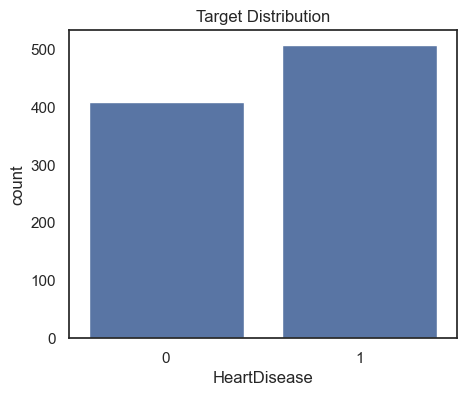

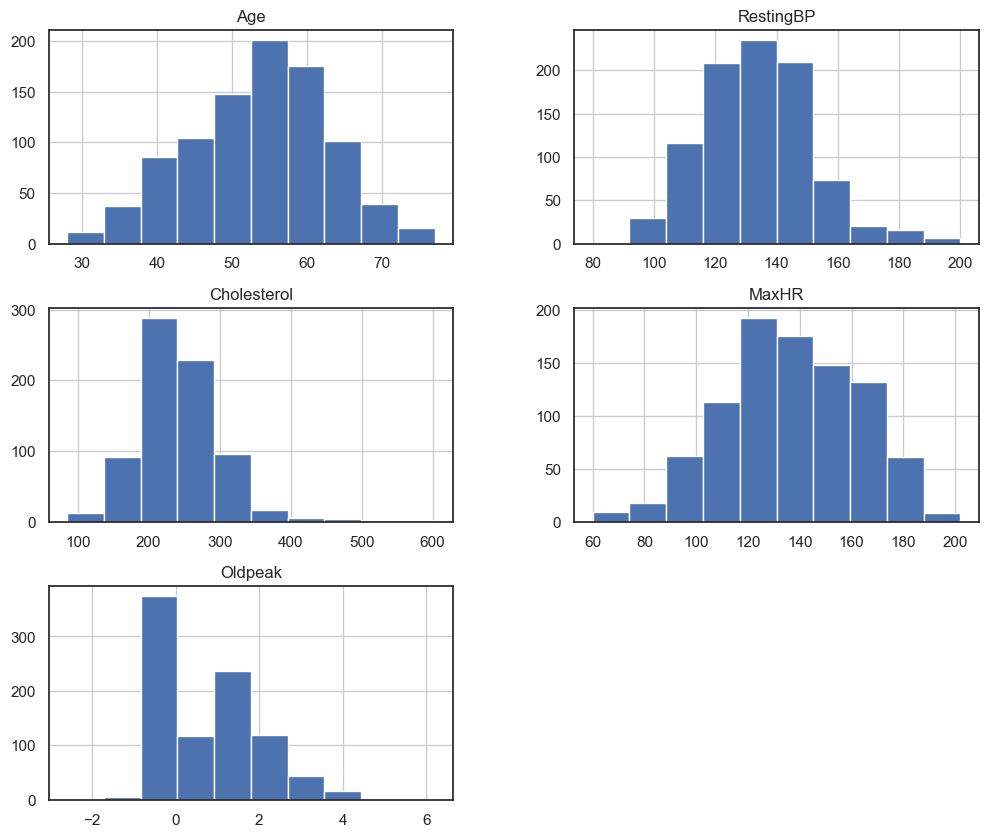

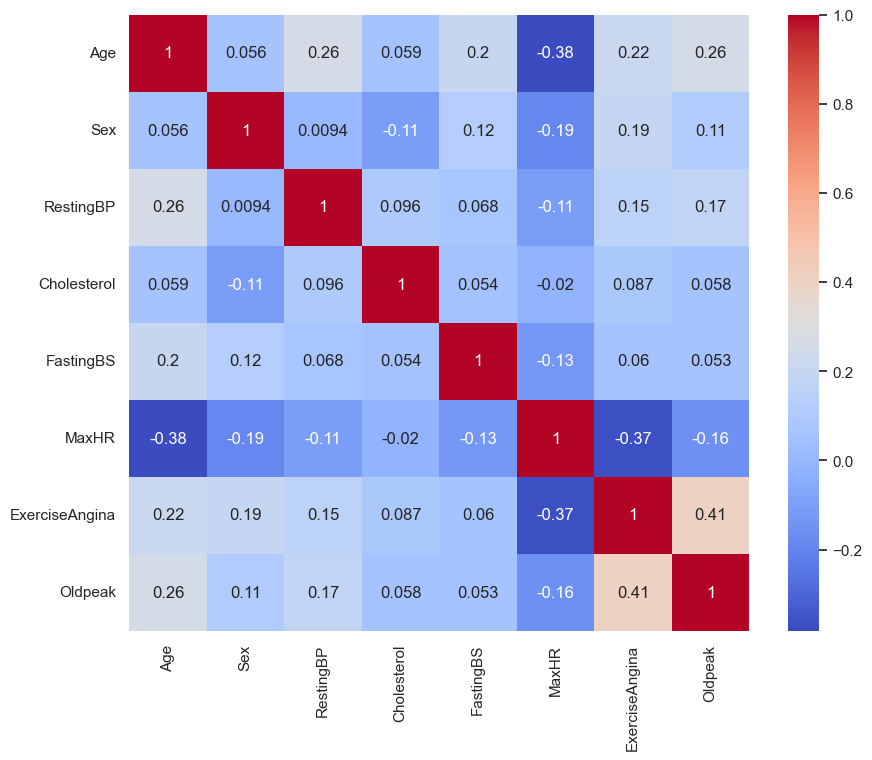

In [6]:
# VISUALIZATION

print("\nTarget Distribution", df['HeartDisease'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='HeartDisease', data=df)
plt.title("Target Distribution")
plt.show()

# Histogram
df[num_cols].hist(figsize=(12,10))
plt.show()
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns='HeartDisease').corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


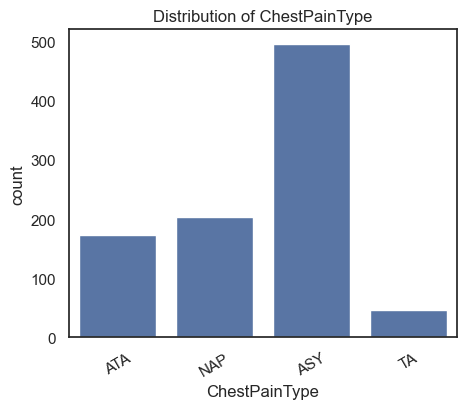

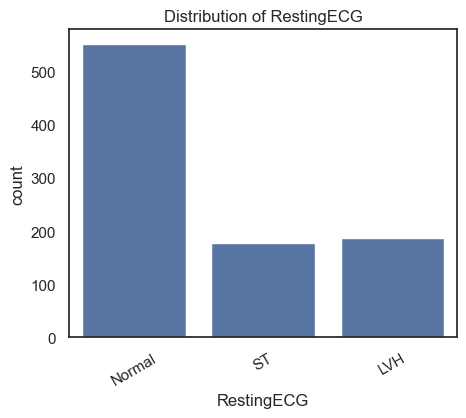

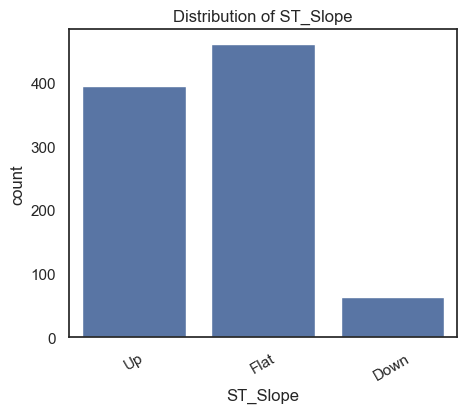

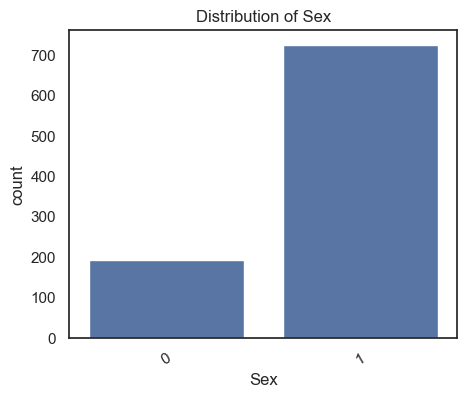

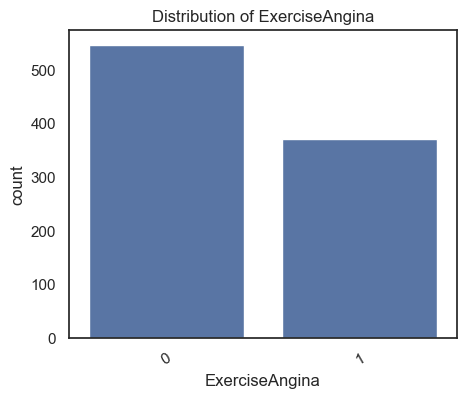

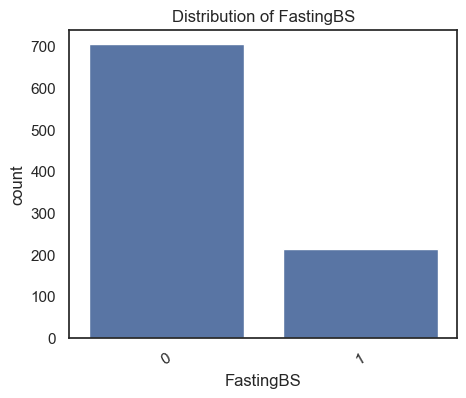

In [7]:
for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.show()
    
for col in bin_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.show()


In [8]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]


# TRAIN TEST SPLIT

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


# using pipelines
num_pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
num_pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])



cat_pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor_lr = ColumnTransformer([
    ('num', num_pipeline_lr, num_cols),
    ('cat', cat_pipeline_lr, cat_cols),
    ('bin', 'passthrough', bin_cols)
    

])

preprocessor_rf = ColumnTransformer([
    ('num', num_pipeline_rf, num_cols),
    ('cat', cat_pipeline_rf, cat_cols),
    ('bin','passthrough',bin_cols)

    
    
])

In [9]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(max_iter=1000))
])
param_grid_lr= {
    'model__solver': ['liblinear', 'lbfgs'],  
    'model__C': [ 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring='recall',   
    n_jobs=-1
)

grid_lr.fit(x_train, y_train)

print("Best LR Params:", grid_lr.best_params_)

lr_best = grid_lr.best_estimator_

y_pred_lr = lr_best.predict(x_test)
lr_probs = lr_best.predict_proba(x_test)[:, 1]


Best LR Params: {'model__C': 0.1, 'model__solver': 'liblinear'}


LOGISTIC REGRESSION 
Accuracy 0.875
Precision 0.8910891089108911
Recall 0.8823529411764706
F1 Score 0.8866995073891626

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.86        82
           1       0.89      0.88      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



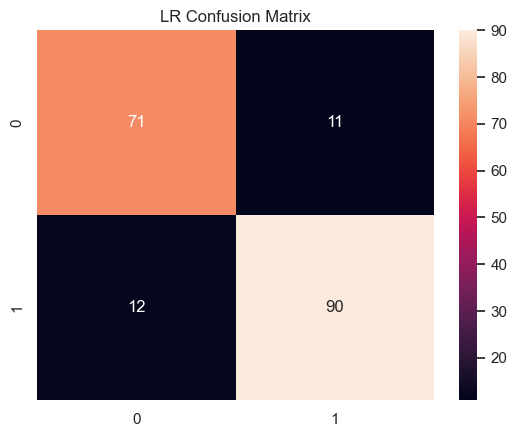

In [10]:


print("LOGISTIC REGRESSION ")
print("Accuracy", accuracy_score(y_test, y_pred_lr))
print("Precision", precision_score(y_test, y_pred_lr))
print("Recall", recall_score(y_test, y_pred_lr))
print("F1 Score", f1_score(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("LR Confusion Matrix")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
plt.show()


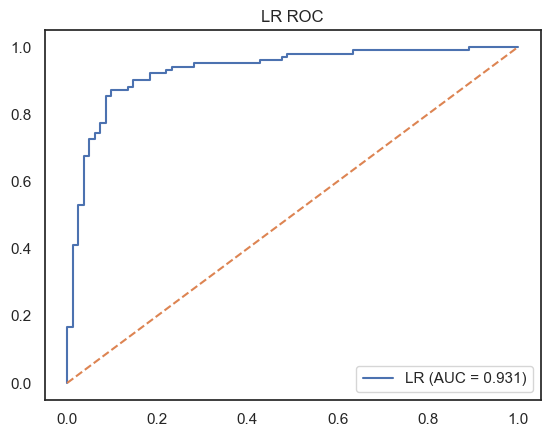

In [11]:

lr_auc = roc_auc_score(y_test, lr_probs)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
plt.figure()
plt.plot(lr_fpr, lr_tpr, label=f"LR (AUC = {lr_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("LR ROC")
plt.show()

In [12]:
# RANDOM FOREST 
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestClassifier(random_state=42))
])


param_dist_rf = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__max_depth': [ 5, 7, 10],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1,2, 3],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': ['balanced'],
    
}
random_rf =RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='recall',   
    n_jobs=-1,
    random_state=42
)

random_rf.fit(x_train, y_train)

print("Best RF Params:", random_rf.best_params_)

rf_best = random_rf.best_estimator_

y_pred_rf = rf_best.predict(x_test)
rf_probs = rf_best.predict_proba(x_test)[:, 1]



Best RF Params: {'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__class_weight': 'balanced'}


RANDOM FOREST 
Accuracy 0.8858695652173914
Precision 0.8932038834951457
Recall 0.9019607843137255
F1 Score 0.8975609756097561

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



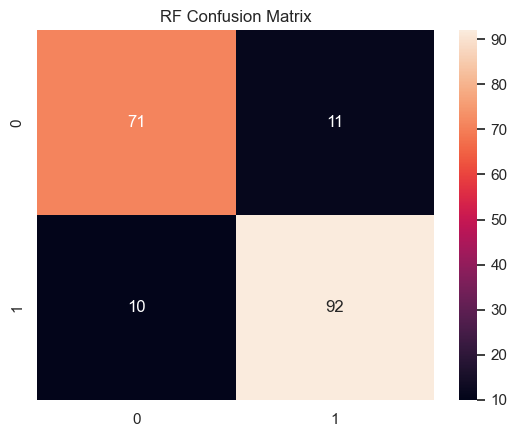

In [13]:

print("RANDOM FOREST ")
print("Accuracy", accuracy_score(y_test, y_pred_rf))
print("Precision", precision_score(y_test, y_pred_rf))
print("Recall", recall_score(y_test, y_pred_rf))
print("F1 Score", f1_score(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("RF Confusion Matrix")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
plt.show()


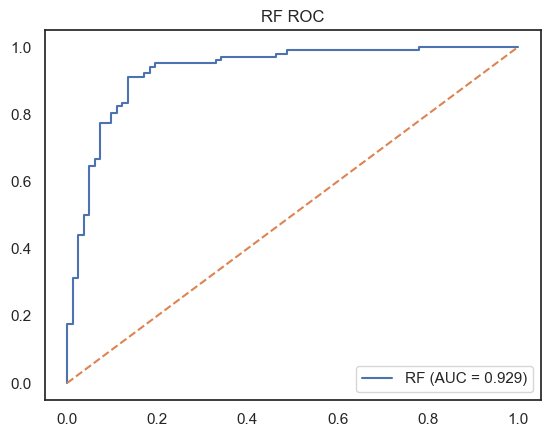

In [14]:

rf_auc = roc_auc_score(y_test, rf_probs)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
plt.figure()
plt.plot(rf_fpr, rf_tpr, label=f"RF (AUC = {rf_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("RF ROC")
plt.show()

In [16]:
# VOTING CLASSIFIER

from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr', lr_best),
        ('rf', rf_best)
    ],
    voting='soft',
    weights=[1,2]

)

voting.fit(x_train, y_train)

y_pred_v = voting.predict(x_test)
v_probs = voting.predict_proba(x_test)[:, 1]


VOTING CLASSIFIER 
Accuracy: 0.8804347826086957
Precision: 0.8921568627450981
Recall: 0.8921568627450981
F1 Score: 0.8921568627450981

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87        82
           1       0.89      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



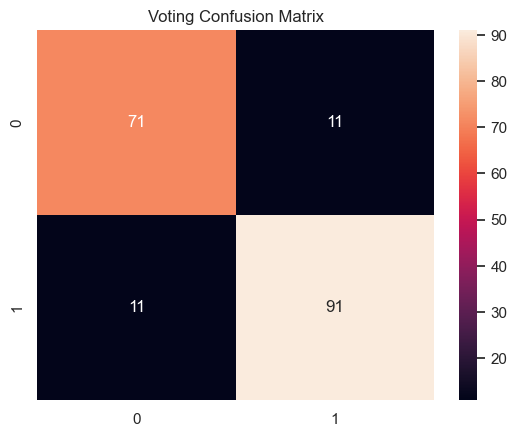

In [17]:

print("VOTING CLASSIFIER ")
print("Accuracy:", accuracy_score(y_test, y_pred_v))
print("Precision:", precision_score(y_test, y_pred_v))
print("Recall:", recall_score(y_test, y_pred_v))
print("F1 Score:", f1_score(y_test, y_pred_v))

sns.heatmap(confusion_matrix(y_test, y_pred_v), annot=True, fmt='d')
plt.title("Voting Confusion Matrix")
print("\nClassification Report:\n", classification_report(y_test, y_pred_v))
plt.show()
v_auc = roc_auc_score(y_test, v_probs)


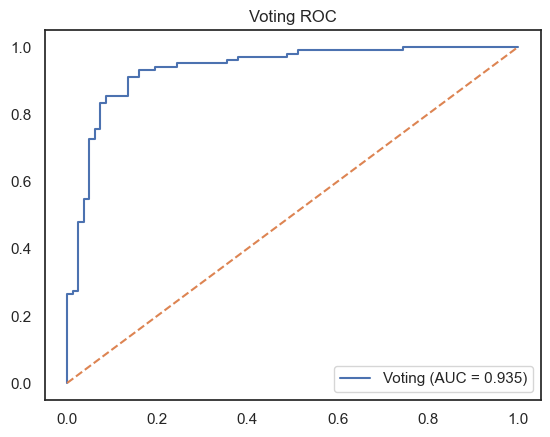

In [18]:

v_fpr, v_tpr, _ = roc_curve(y_test, v_probs)
plt.figure()
plt.plot(v_fpr, v_tpr, label=f"Voting (AUC = {v_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("Voting ROC")
plt.show()

In [19]:
import pickle

pickle.dump(lr_best, open("lr_model.pkl", "wb"))
pickle.dump(rf_best, open("rf_model.pkl", "wb"))
pickle.dump(voting, open("voting_model.pkl", "wb"))